### 6. For an RBF Kernel SVM, create a heatmap showing the validation accuracy for different combinations of 𝐶 (Regularization) and 𝛾 (Kernel width). Explain what happens to the decision boundary when 𝛾 is set too high.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

### Load and Scale Data

In [13]:
wine = load_wine()
X = wine.data
y = wine.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Define Parameter Grid

In [15]:
C_values = [0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1, 10]

scores = np.zeros((len(C_values), len(gamma_values)))

### Train Models

In [18]:
for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):

        model = SVC(kernel='rbf', C=C, gamma=gamma)
        cv_scores = cross_val_score(model, X_scaled, y, cv=5)
        scores[i, j] = np.mean(cv_scores)

### Plot Heatmap

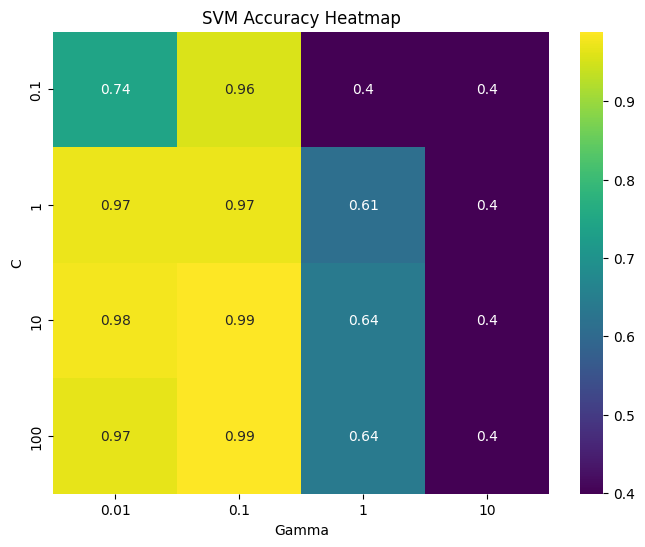

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(scores,
            annot=True,
            xticklabels=gamma_values,
            yticklabels=C_values,
            cmap="viridis")

plt.xlabel("Gamma")
plt.ylabel("C")
plt.title("SVM Accuracy Heatmap")
plt.show()

If gamma is big:

* Even small distance differences cause huge change

* Model memorizes individual points

* Decision boundary becomes extremely complex.

Small gamma:

* Influence region is very large

* Boundary becomes too smooth

* Cannot capture nonlinear structure

The heatmap shows that both C and gamma significantly influence model performance. Small values of C and gamma lead to underfitting due to overly smooth decision boundaries. Large values of both parameters lead to overfitting, where the model captures noise in the training data. The optimal performance is observed at moderate values of C and gamma, which provide a balance between bias and variance.